# Final Project | Time Series Analysis

Topic: New York State Private Sector Compensation

Prepared By: Kyle McCormack

Date: May 6, 2027

# Setup

In [1]:
#Libraries

#Data manipulation
import pandas as pd
import numpy as np

#Utilities
import os
import json
from datetime import date
from dateutil.relativedelta import relativedelta

#visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import plotly.express as px

plt.rcParams['figure.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['grid.color'] = 'darkgray'
plt.rcParams['grid.alpha'] = 0.65
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['lines.linewidth'] = 3

palette = [
    "#300049",  # purple (primary)
    "#00838F",  # teal
    "#D47A1F",  # orange
    "#C2185B"]   # magenta

#Time series modeling & analysis
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

#Tree-based models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

In [26]:
#custom functions

#axis formatting

def thou_form(x,pos):
    return f'{x:0,.0f}'
def million_form(x,pos):
    return f'${x/1e6:0,.0f}M'

#========================================================================

#stationarity analysis
from IPython.display import display

def adf_table(series, name):
    stat, pvalue, used_lag, nobs, crit_vals, *_ = adfuller(
        np.asarray(series).astype(float),
        autolag='AIC'
    )
    out = pd.DataFrame({
        'Series': [name],
        'ADF statistic': [round(stat, 3)],
        'p value': [round(pvalue, 4)],
        'Used lags': [used_lag],
        'Critical value 5%': [round(crit_vals['5%'], 3)],
        'Decision at 5%': [
            'Stationary' if pvalue < 0.05 else 'Not stationary'
        ]}).set_index('Series')
    display(out)
    return out

def stationary_plots(x,title):
    fig, axes = plt.subplots(1,2,figsize=(12,4))
    plot_acf(x.values,ax=axes[0])
    axes[0].set_title('ACF Correlogram')
    plot_pacf(x.values,ax=axes[1])
    axes[1].set_title('PACF Correlogram')
    plt.suptitle(title)
    plt.show();

#========================================================================

#ETS modeling
def ets_model(
    train_series: pd.Series,
    horizon: int,
    trend: str | None,
    damped_trend: bool,
):
    """
    Fit a single ETS model and return:
    1) forecast series,
    2) fitted parameters,
    3) fitted model object.
    """
    model = ExponentialSmoothing(
        train_series,
        trend=trend,
        damped_trend=damped_trend,
        seasonal=None,
    )
    fit_model = model.fit(optimized=True)
    forecast = fit_model.forecast(horizon)  # keeps aligned future index when freq is set
    model_params = fit_model.params

    return forecast, model_params, fit_model


In [ ]:
#shorten industry descriptions
industry_map = {
'Wholesale trade':'Wholesale trade',
 'Retail trade': 'Retail trade',
 'Transportation and warehousing':'Transport',
 'Information':'Technology',
 'Finance and insurance':'Finance',
 'Real estate and rental and leasing':'Real estate',
 'Professional, scientific, and technical services':'Professional/Technical services',
 'Management of companies and enterprises':'Management',
 'Administrative and support and waste management and remediation services':'Admin/support services',
 'Educational services':'Education',
 'svcs care and social assistance':'svcs care',
 'Arts, entertainment, and recreation':'Entertainment',
 'Accommodation and food services':'Hospitality',
 'Other services (except government and government enterprises)':'Other private services'
 }

In [5]:
#data load

df = (pd.read_csv('data.csv',skiprows=3)
    .dropna(subset=['Description'])
    .drop(columns=['GeoFIPS','GeoName'])
    .set_index('LineCode')
    .melt(id_vars=['Description'],
        var_name = 'period',
        value_name='compensation',
        ignore_index = False)
        )
df.index.name = 'code'
df.columns = ['industry','period','compensation']
df['industry'] = df['industry'].str.strip().map(industry_map)
df['period'] = (df['period']
    .str.replace(
        r'(\d{4}):Q1', 
        r'\1-01-01',
        regex=True
    )
    .str.replace(
        r'(\d{4}):Q2', 
        r'\1-04-01',
        regex=True
    )
    .str.replace(
        r'(\d{4}):Q3', 
        r'\1-07-01',
        regex=True
    )
    .str.replace(
        r'(\d{4}):Q4', 
        r'\1-10-01',
        regex=True
    )
)
df['period'] = pd.to_datetime(df['period'], format='%Y-%m-%d')
df['year'] = df['period'].dt.year
df.head()

,industry,period,compensation,year
code,,,,
600.0,Wholesale trade,1998-01-01,21243968.0,1998
700.0,Retail trade,1998-01-01,21947724.0,1998
800.0,Transport,1998-01-01,9582764.0,1998
900.0,Technology,1998-01-01,19137684.0,1998
1000.0,Finance,1998-01-01,62067196.0,1998


# Exploratory Data Analysis

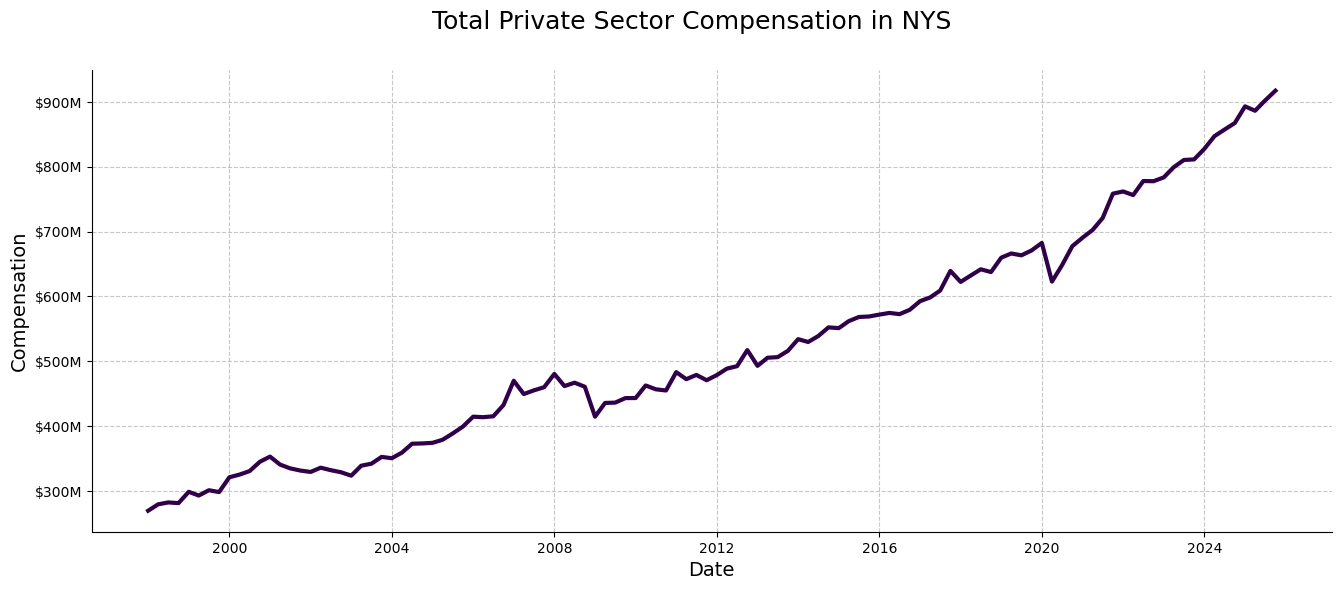

In [120]:
plt.figure(figsize=(16,6))
sns.lineplot(data=df,
             x='period',
             y='compensation',
             estimator='sum',
             errorbar=None,
             color = palette[0]
             )
plt.suptitle('Total Private Sector Compensation in NYS')
plt.xlabel('Date')
plt.ylabel('Compensation')
plt.grid()
plt.gca().yaxis.set_major_formatter(million_form)
plt.show();

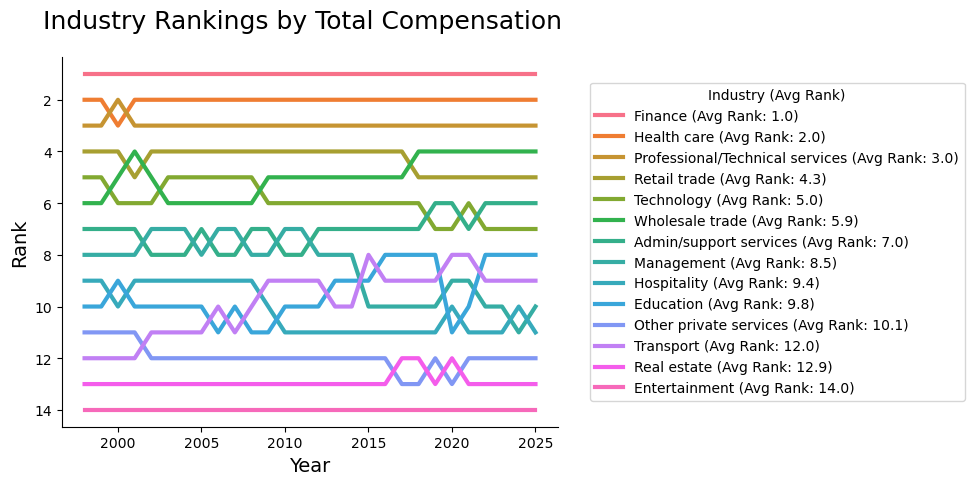

In [121]:
#Industry rank by year

year_df = (
    df[['industry', 'year', 'compensation']]
    .groupby(['year', 'industry'], as_index=False)
    .agg(compensation=('compensation', 'sum'))
)
year_df['rank'] = (
    year_df
    .groupby('year')['compensation']
    .rank(method='dense', ascending=False)
)
year_df = year_df.sort_values(by=['year','compensation'],ascending=[True,False])


avg_rank_dict = (year_df.groupby('industry')['rank']
                 .mean()
                 .round(1)
                 .sort_values()
                 .to_dict()
                 )
#Plot
sns.lineplot(data=year_df,
             x='year',
             y='rank',
             hue='industry',
             markers=True
)

#Legend
handles, labels = plt.gca().get_legend_handles_labels()
# Map industry name -> handle
handle_dict = dict(zip(labels, handles))

# Sort industries by average rank
sorted_industries = sorted(
    avg_rank_dict, #type: ignore
    key=avg_rank_dict.get #type:ignore
)

# Rebuild ordered handles and labels
sorted_handles = [
    handle_dict[ind]
    for ind in sorted_industries
]

sorted_labels = [
    f'{ind} (Avg Rank: {avg_rank_dict[ind]:.1f})'
    for ind in sorted_industries
]
plt.legend(handles=handles,
           labels=sorted_labels,
           title='Industry (Avg Rank)',
           bbox_to_anchor=(1.05,0.95))

#axes
plt.gca().invert_yaxis()

#Labels
plt.ylabel('Rank')
plt.xlabel('Year')
plt.suptitle('Industry Rankings by Total Compensation')
plt.show();

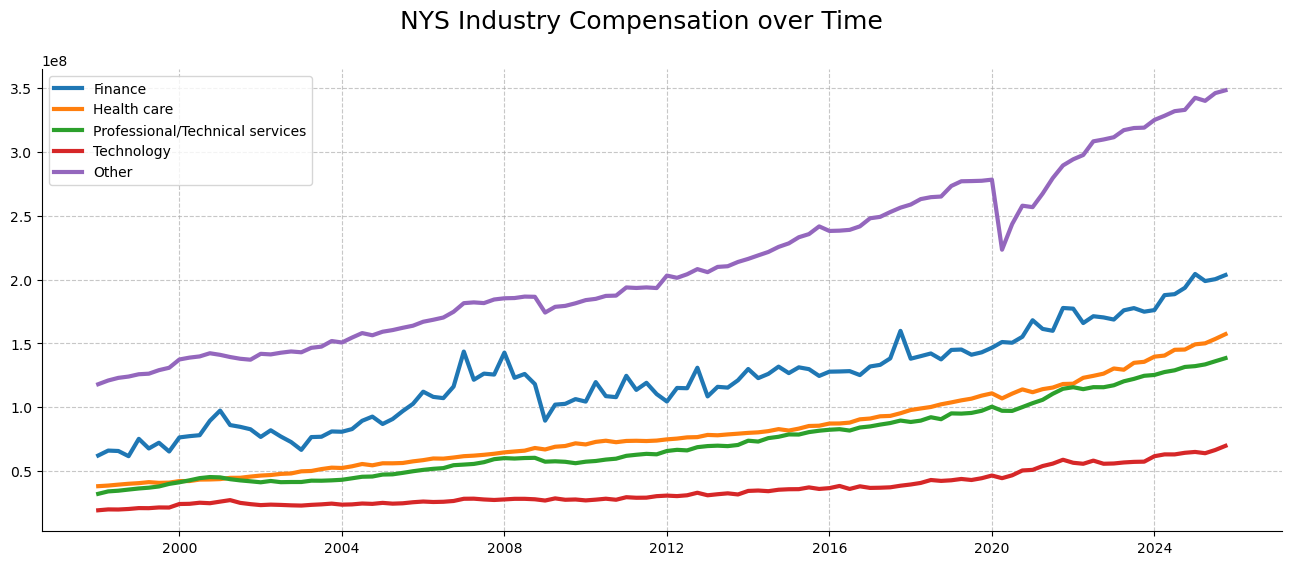

In [78]:
top_industries = ['Finance','Health care','Professional/Technical services','Technology']
df['industry_group'] = df['industry'].apply(lambda x:
                                            x if x in top_industries else 'Other')


plt.figure(figsize=(16,6))

for group in (top_industries + ['Other']):
    temp_df = (df.loc[df['industry_group']==group]
               .groupby('period',as_index=False)['compensation']
               .sum()
               )
    plt.plot(temp_df['period'],
             temp_df['compensation'],
             label=group)

plt.grid()
plt.legend()
plt.suptitle('NYS Industry Compensation over Time')
plt.show();

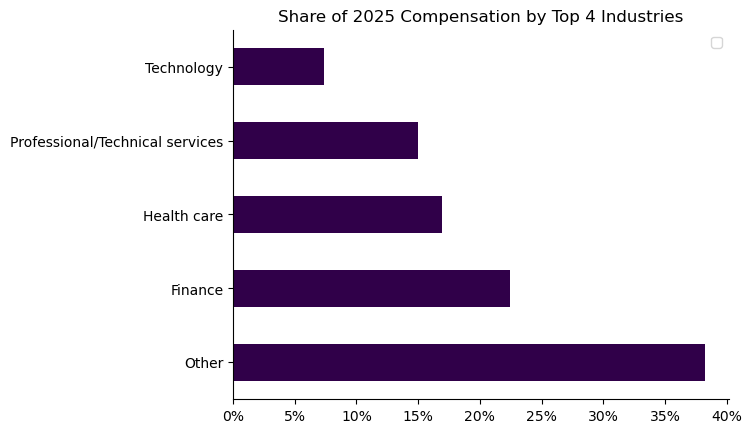

In [123]:
df2025 = (df
          .loc[df['period'].dt.year == 2025,
               ['industry_group','compensation']]
               .groupby('industry_group')
               .sum()
               .sort_values(by='compensation',
                            ascending=False))
(df2025/df2025.sum()).plot(kind='barh',color=palette[0],title='Share of 2025 Compensation by Top 4 Industries')
plt.legend([])
plt.ylabel('')
plt.xlabel('')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.0%}'))
plt.show();

# Modeling

In [94]:
#series
series_index = pd.date_range(df['period'].min(),
                             end=df['period'].max(),
                             freq='QS')

finance = pd.Series(df.loc[df['industry']==top_industries[0],'compensation'].reset_index(drop=True).values,
                    index=series_index)
health = pd.Series(df.loc[df['industry']==top_industries[1],'compensation'].reset_index(drop=True).values,
                    index=series_index)
prof_svcs = pd.Series(df.loc[df['industry']==top_industries[2],'compensation'].reset_index(drop=True).values,
                    index=series_index)
tech = pd.Series(df.loc[df['industry']==top_industries[3],'compensation'].reset_index(drop=True).values,
                    index=series_index)

series_list = [finance,health,prof_svcs,tech]


In [ ]:
#training/testing periods
n = 32

def train_test_split(series, test_n = n):
    train_end = series_index.max() - relativedelta(months=n*3)
    train = series[series.index <= train_end]
    test = series[series.index > train_end]
    return train, test

def train_test_split_diff(series, test_n = n):
    series = series.diff().dropna()
    train_end = series_index.max() - relativedelta(months=n*3)
    train = series[series.index <= train_end]
    test = series[series.index > train_end]
    return train, test


fin_train, fin_test = train_test_split(fin_diff)
health_train, health_test = train_test_split(health_diff)
svcs_train, svcs_test = train_test_split(svcs_diff)
tech_train, tech_test = train_test_split(tech_diff)


## Exponential Smoothing Models

In [9]:
def plot_ets_forecast(series, forecast, fitted_model, title='ETS Forecast'):
    plt.figure(figsize=(12, 4))
    plt.plot(series,
             c=palette[0],
             label='Actuals')
    plt.plot(fitted_model.fittedvalues,
             c=palette[1],
             label='Fitted Values')
    plt.plot(forecast,
             c=palette[2],
             linestyle='--',
             label='Forecast')
    plt.gca().yaxis.set_major_formatter(million_form)
    plt.grid()
    plt.suptitle(title)
    plt.legend()
    plt.show()

### Model Fit/Train

In [ ]:
#ETS Models
finance_fc, finance_params, finance_model = ets_model(train_series = finance,
                                                      horizon = n,
                                                      trend = 'add',
                                                      damped_trend=False)
health_fc, health_params, health_model = ets_model(train_series = health,
                                                   horizon = n,
                                                   trend = 'add',
                                                   damped_trend = False)
svcs_fc, svcs_params, svcs_model = ets_model(train_series = prof_svcs,
                                                   horizon = n,
                                                   trend = 'add',
                                                   damped_trend = False)
tech_fc, tech_params, tech_model = ets_model(train_series = tech,
                                                   horizon = n,
                                                   trend = 'add',
                                                   damped_trend = False)

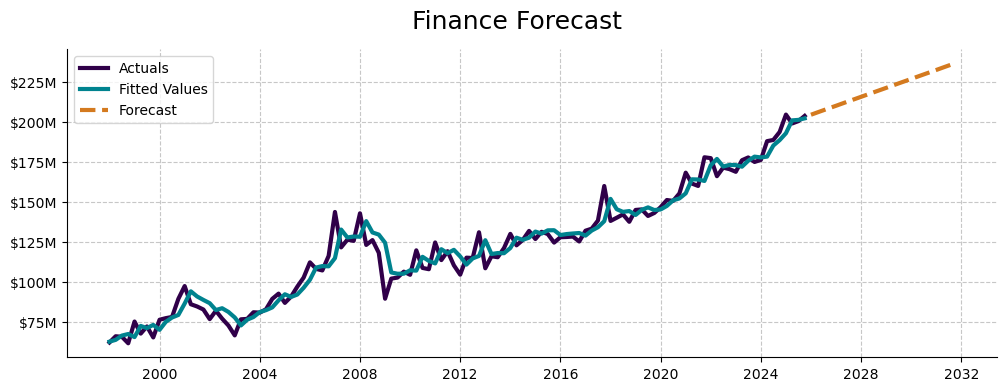

In [11]:
plot_ets_forecast(finance,finance_fc,finance_model,title='Finance Forecast')

### Residuals

## ARIMA Modeling

### Stationarity Check

,ADF statistic,p value,Used lags,Critical value 5%,Decision at 5%
Series,,,,,
Finance,-4.856,0.0,8,-2.89,Stationary


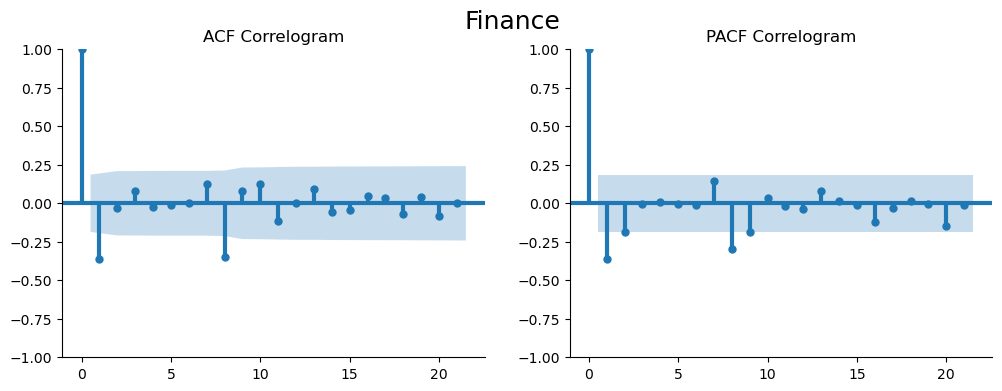

,ADF statistic,p value,Used lags,Critical value 5%,Decision at 5%
Series,,,,,
Health care,-0.687,0.85,4,-2.889,Not stationary


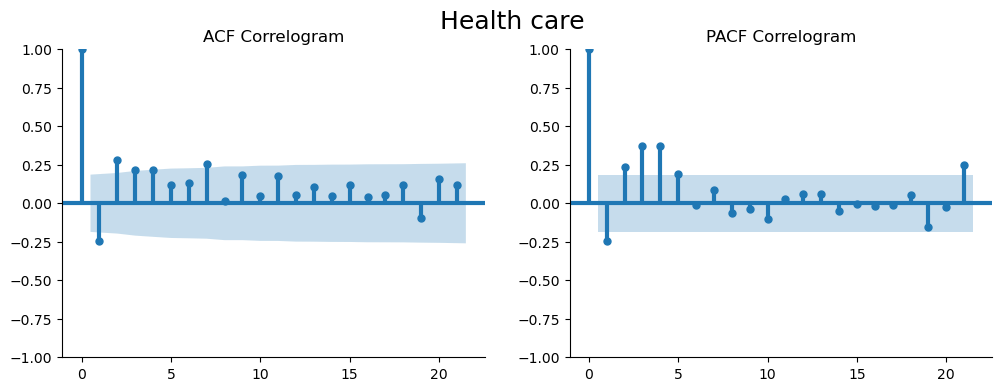

,ADF statistic,p value,Used lags,Critical value 5%,Decision at 5%
Series,,,,,
Professional/Technical Services,-2.615,0.0899,6,-2.89,Not stationary


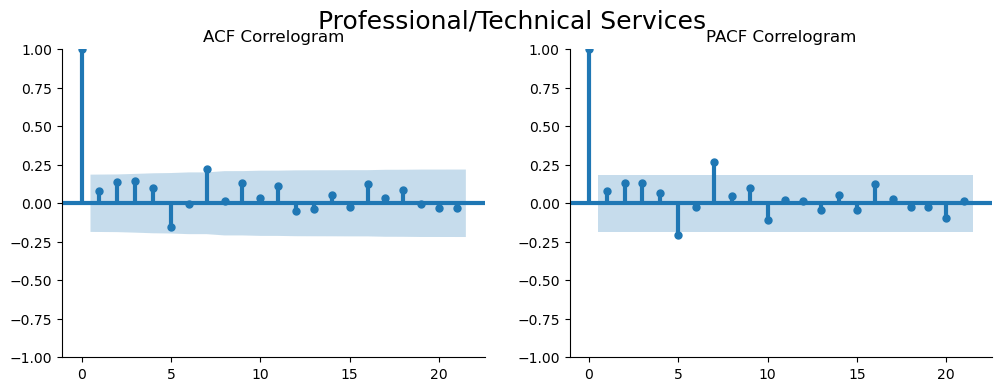

,ADF statistic,p value,Used lags,Critical value 5%,Decision at 5%
Series,,,,,
Technology,-4.473,0.0002,2,-2.889,Stationary


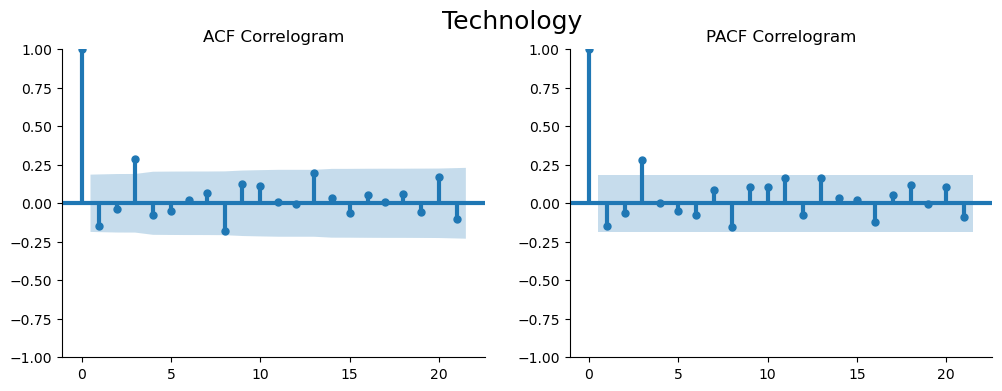

In [28]:
adf_table(fin_diff,'Finance')
stationary_plots(fin_diff,'Finance')
#=======================================
adf_table(health_diff,'Health care')
stationary_plots(health_diff,'Health care')
#=======================================
adf_table(svcs_diff,'Professional/Technical Services')
stationary_plots(svcs_diff,'Professional/Technical Services')
#=======================================
adf_table(tech_diff,'Technology')
stationary_plots(tech_diff,'Technology')

### Model Fit/Train

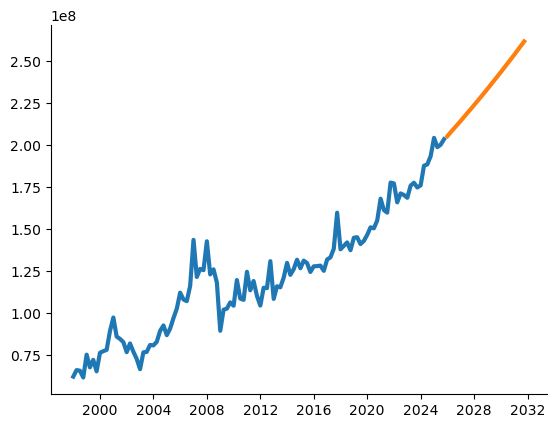

In [56]:
fin_try = ARIMA(fin_diff,
                order=(1,0,0),
                trend='t')
fin_fit = fin_try.fit()
fin_fc = fin_fit.get_forecast(HORIZON)
fin_pred_mean = finance.iloc[-1] + np.cumsum(fin_fc.predicted_mean)
plt.plot(finance)
plt.plot(fin_pred_mean)
plt.show();

### Residuals

## Random Forest Modeling

### Feature Engineering

In [92]:
def get_feature_matrix(series,lags = [1,2,4,8,12]):
    out = pd.Series(series,
                    index = series.index)
    
    for lag in lags:
        out[f'lag_{lag}'] = series.shift(lag)
    
    #harmonics
    month = series.index.month
    out['month_cos'] = np.cos(2 * np.pi * month)
    out['month_sin'] = np.sin(2 * np.pi * month)

    #rolling averages
    out['4q_mean_lvl'] = series.rolling(4).mean()
    out['yoy_change'] = (series.shift(4) / series)

    return out

### Model Fit/Train

### Residuals

## Model Evaluation

In [57]:
def model_metrics(y_true,y_pred,series_label,model_label = ['ETS','ARIMA','Random Forest']):
    mae = mean_absolute_error(y_true=y_true,
                              y_pred=y_pred)
    mape = mean_absolute_percentage_error(y_true=y_true,
                                          y_pred=y_pred)
    out = pd.DataFrame({
        'Series':series_label,
        'Model': model_label,
        'MAE': mae,
        'MAPE': mape
    })
    return out